In [1]:
import torch
import numpy as np
import pandas as pd
from datasets import load_dataset, concatenate_datasets, Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

In [ ]:
# Detects and sets device for all GPU operations
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Using device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
else:
    print("  WARNING: CUDA not available, falling back to CPU (training will be slow)")


In [2]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

model_path = "./hallucination_model_v1" 
ogmodel = AutoModelForSequenceClassification.from_pretrained(model_path)
tokenizer = AutoTokenizer.from_pretrained(model_path)

print("✅ Model restored and ready for Phase 2!")

✅ Model restored and ready for Phase 2!


In [ ]:
def prepare_unified_dataset_v3():
    all_data = []

    # 1. HaluEval - Usually script-free, but add flag just in case
    halu = load_dataset("pminervini/HaluEval", "qa", split="data", trust_remote_code=True)
    for item in halu.select(range(5000)):
        all_data.append({"text": f"Context: {item['knowledge']} | Q: {item['question']} | A: {item['right_answer']}", "label": 0})
        all_data.append({"text": f"Context: {item['knowledge']} | Q: {item['question']} | A: {item['hallucinated_answer']}", "label": 1})

    # 2. TruthfulQA - Uses JSON, usually doesn't need the flag
    tqa = load_dataset("truthful_qa", "generation", split="validation")
    for item in tqa:
        all_data.append({"text": f"Q: {item['question']} | A: {item['best_answer']}", "label": 0})
        all_data.append({"text": f"Q: {item['question']} | A: {item['incorrect_answers'][0]}", "label": 1})

    # 3. FEVER (The 3rd Dataset) - Direct Parquet Loading
    # If standard loading fails, we use the Parquet export branch
    try:
        fever = load_dataset("fever", "v1.0", split="train", trust_remote_code=True)
    except Exception as e:
        print("Standard FEVER load failed, switching to Parquet...")
        fever = load_dataset("parquet", data_files="hf://datasets/fever/fever@refs/convert/parquet/v1.0/train/*.parquet", split="train")

    fever_filtered = fever.filter(lambda x: x["label"] in ["SUPPORTS", "REFUTES"]).shuffle(seed=42).select(range(5000))

    for item in fever_filtered:
        label = 0 if item["label"] == "SUPPORTS" else 1
        all_data.append({"text": f"Fact Check: {item['claim']}", "label": label})

    combined_ds = Dataset.from_list(all_data).shuffle(seed=42)
    return combined_ds.train_test_split(test_size=0.1)

dataset = prepare_unified_dataset_v3()
print(f"Dataset Size: {len(dataset['train'])} rows")
print(f"Labels: {pd.Series(dataset['train']['label']).value_counts()}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'pminervini/HaluEval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'pminervini/HaluEval' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to 

README.md: 0.00B [00:00, ?B/s]

qa/data-00000-of-00001.parquet:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

...

Standard FEVER load failed, switching to Parquet...


v1.0/train/0000.parquet:   0%|          | 0.00/12.4M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/311431 [00:00<?, ? examples/s]

Dataset Size: 14970 rows
Labels: 0    8534
1    6436
Name: count, dtype: int64


In [ ]:
# Assuming 'dataset' is your current merged dataset
minority_count = 6463 # The count for Label 1

# Separate and Downsample
ds_truth = dataset['train'].filter(lambda x: x['label'] == 0).shuffle(seed=42).select(range(minority_count))
ds_hallu = dataset['train'].filter(lambda x: x['label'] == 1)

# Re-merge to a perfect 12,926 sample dataset
balanced_dataset = concatenate_datasets([ds_truth, ds_hallu]).shuffle(seed=42)

print(f"Balanced Dataset: {len(balanced_dataset)} samples")
print(f"New Split: 50% / 50%")

Filter:   0%|          | 0/14970 [00:00<?, ? examples/s]

Filter:   0%|          | 0/14970 [00:00<?, ? examples/s]

Balanced Dataset: 12899 samples
New Split: 50% / 50%


In [ ]:
# Tokenize the Balanced Dataset
def tokenize_function(examples):
    return tokenizer(examples["text"], truncation=True, padding="max_length", max_length=512)


tokenized_datasets = balanced_dataset.map(tokenize_function, batched=True)
# Split it for evaluation
tokenized_split = tokenized_datasets.train_test_split(test_size=0.1)

Map:   0%|          | 0/12899 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from transformers import Trainer, TrainingArguments

def plot_final_results(current_trainer, test_dataset):
    print("🔄 Generating predictions (this may take a minute)...")

    # 1. Get predictions on the test set
    outputs = current_trainer.predict(test_dataset)
    y_pred = np.argmax(outputs.predictions, axis=-1)
    y_true = outputs.label_ids

    # 2. Calculate and Print Core Metrics
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"\n✨ FINAL METRICS ✨")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1 Score: {f1:.4f}\n")

    # 3. Create Confusion Matrix (Normalized)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    # 4. Plotting
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=["Truth (0)", "Hallucination (1)"],
                yticklabels=["Truth (0)", "Hallucination (1)"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Hallucination Detector: Confusion Matrix")
    plt.show()

🔄 Generating predictions (this may take a minute)...


W0112 12:51:14.095000 2662 torch/_inductor/utils.py:1558] [1/0_1] Not enough SMs to use max_autotune_gemm mode



✨ FINAL METRICS ✨
Accuracy: 0.9364
F1 Score: 0.9395



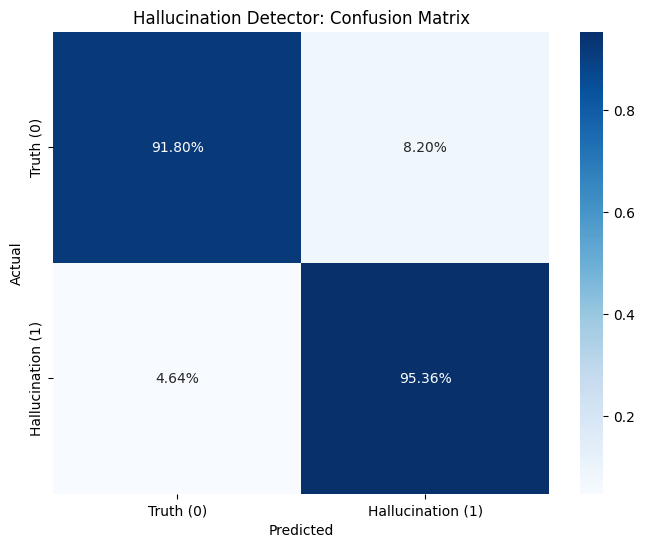

In [ ]:
args = TrainingArguments(output_dir="./temp", fp16=True,report_to="none")
trainer = Trainer(model=ogmodel, args=args, processing_class=tokenizer)
plot_final_results(trainer, tokenized_split["test"])

In [ ]:
# @title
import pandas as pd
from datasets import Dataset

part_1_samples = [
    # --- GEOGRAPHY: The "Mental Map" Traps ---
    {"text": "The United Kingdom and Great Britain are geographically the same entity.", "label": 1}, # Hallucination (GB is the island, UK is the country)
    {"text": "Vatican City is the smallest independent state in the world by both area and population.", "label": 0},
    {"text": "The Panama Canal allows ships to travel between the Atlantic and Pacific Oceans.", "label": 0},
    {"text": "Geneva is the capital city of Switzerland.", "label": 1}, # (It's Bern)
    {"text": "Mount Whitney is the highest peak in the contiguous United States.", "label": 0},
    {"text": "The Dead Sea is the lowest point of elevation on the Earth's land surface.", "label": 0},
    {"text": "Lagos is the capital and largest city of Nigeria.", "label": 1}, # (Capital is Abuja)
    {"text": "Iceland is actually greener than Greenland, which is mostly covered in ice.", "label": 0},
    {"text": "The Nile River flows from South to North, emptying into the Mediterranean Sea.", "label": 0},
    {"text": "The city of Venice is built on a group of 118 small islands separated by canals.", "label": 0},
    {"text": "Rio de Janeiro is the capital city of Brazil.", "label": 1}, # (It's Brasilia)
    {"text": "The Great Wall of China is the only man-made structure visible from the moon with the naked eye.", "label": 1}, # (Common Myth)
    {"text": "Russia spans across eleven different time zones.", "label": 0},
    {"text": "The Gobi Desert is located primarily in Southern Africa.", "label": 1}, # (Asia - Mongolia/China)
    {"text": "The Rhine River is the longest river located entirely within France.", "label": 1}, # (Loire is the longest in France)
    {"text": "Australia is both a country and the world's smallest continent.", "label": 0},
    {"text": "The Amazon Rainforest produces approximately 20% of the Earth's oxygen.", "label": 1}, # (Scientific Myth - it's closer to 6-9%)
    {"text": "Canada has more lakes than the rest of the world's lakes combined.", "label": 0},
    {"text": "The Atacama Desert in Chile is known as the driest non-polar place on Earth.", "label": 0},
    {"text": "The Strait of Gibraltar connects the Atlantic Ocean to the Mediterranean Sea.", "label": 0},

    # --- HISTORY: The "Famous Figure" Swaps ---
    {"text": "Marie Antoinette famously said 'Let them eat cake' when told the peasants had no bread.", "label": 1}, # (Historical Myth)
    {"text": "Nelson Mandela was the first black president of South Africa.", "label": 0},
    {"text": "The United States declared independence from Great Britain in the year 1776.", "label": 0},
    {"text": "Alexander Graham Bell is credited with patenting the first practical telephone.", "label": 0},
    {"text": "Napoleon Bonaparte was exceptionally short for his time, measuring only 5 feet tall.", "label": 1}, # (Myth - he was average height)
    {"text": "The Magna Carta was signed by King John at Runnymede in 1215.", "label": 0},
    {"text": "Christopher Columbus was the first European to discover the American mainland.", "label": 1}, # (Leif Erikson was earlier)
    {"text": "The Wright brothers made their first flight at Kitty Hawk, North Carolina.", "label": 0},
    {"text": "Winston Churchill was the Prime Minister of the UK for the entire duration of WWI.", "label": 1}, # (WWII)
    {"text": "The Apollo 11 mission successfully landed the first humans on the moon in 1969.", "label": 0},
    {"text": "Mahatma Gandhi led the Salt March in 1930 to protest the British salt monopoly in India.", "label": 0},
    {"text": "George Washington had wooden teeth throughout his presidency.", "label": 1}, # (Myth - they were ivory/metal/human)
    {"text": "The Berlin Wall was constructed in 1961 to divide East and West Berlin.", "label": 0},
    {"text": "Albert Einstein was offered the presidency of Israel in 1952 but declined.", "label": 0},
    {"text": "Abraham Lincoln was the primary author of the U.S. Constitution.", "label": 1}, # (James Madison)
    {"text": "The Titanic sank on its maiden voyage after hitting an iceberg in 1912.", "label": 0},
    {"text": "The Renaissance began in Italy during the 14th century.", "label": 0},
    {"text": "The Ottoman Empire officially ended shortly after the conclusion of World War I.", "label": 0},
    {"text": "Benjamin Franklin was the first President of the United States.", "label": 1}, # (Washington)
    {"text": "Julius Caesar was assassinated on the Ides of March in 44 BC.", "label": 0},

    # --- SCIENCE: The "Strange but True" vs "Plausible Lies" ---
    {"text": "A day on Venus is longer than a year on Venus.", "label": 0},
    {"text": "Sound travels approximately four times faster in water than it does in air.", "label": 0},
    {"text": "Humans use only 10% of their brains at any given time.", "label": 1}, # (Myth)
    {"text": "Honey is the only food that includes all the substances necessary to sustain life.", "label": 0},
    {"text": "The human heart has five chambers to ensure efficient blood flow.", "label": 1}, # (It has 4)
    {"text": "Bananas grow on giant herbaceous plants, not trees.", "label": 0},
    {"text": "Light from the Sun takes about 8 minutes and 20 seconds to reach Earth.", "label": 0},
    {"text": "Sharks are older than trees, having existed for over 400 million years.", "label": 0},
    {"text": "Gold is a liquid at room temperature if it is 24-karat pure.", "label": 1}, # (Solid)
    {"text": "Water can boil and freeze at the same time under specific pressure conditions.", "label": 0}, # (Triple Point)
    {"text": "The speed of light in a vacuum is approximately 299,792 kilometers per second.", "label": 0},
    {"text": "Bats are blind and rely solely on echolocation to navigate.", "label": 1}, # (Myth - they can see)
    {"text": "An octopus has three hearts and blue blood.", "label": 0},
    {"text": "Lightning never strikes the same place twice.", "label": 1}, # (Myth)
    {"text": "The chemical symbol for Gold is Au.", "label": 0},
    {"text": "Cows have four stomachs to help digest tough plant fibers.", "label": 1}, # (One stomach, four compartments)
    {"text": "Diamond is the hardest naturally occurring substance on Earth.", "label": 0},
    {"text": "The Earth's core is primarily composed of liquid magnesium.", "label": 1}, # (Iron and Nickel)
    {"text": "A single bolt of lightning contains enough energy to toast 100,000 slices of bread.", "label": 0},
    {"text": "Bulls are enraged by the color red during bullfights.", "label": 1}, # (Myth - they react to movement)

    # --- TECHNOLOGY & DIGITAL: The "Abbreviation & Founder" Swaps ---
    {"text": "Bill Gates and Paul Allen co-founded Microsoft in 1975.", "label": 0},
    {"text": "HTTP stands for HyperText Transfer Protocol.", "label": 0},
    {"text": "The 'I' in iPhone originally stood for 'Internet'.", "label": 0},
    {"text": "Steve Jobs created the first computer mouse out of a block of wood.", "label": 1}, # (Douglas Engelbart)
    {"text": "The first domain name ever registered was symbolics.com.", "label": 0},
    {"text": "Binary code uses three digits: 0, 1, and 2.", "label": 1},
    {"text": "The World Wide Web was invented by Tim Berners-Lee while at CERN.", "label": 0},
    {"text": "Python was named after the popular BBC comedy show 'Monty Python's Flying Circus'.", "label": 0},
    {"text": "RAM stands for Read Access Memory.", "label": 1}, # (Random)
    {"text": "Mark Zuckerberg founded Facebook while studying at Harvard University.", "label": 0},
    {"text": "The first electronic digital computer, ENIAC, was built during WWII.", "label": 0},
    {"text": "Bluetooth technology was named after a 10th-century Scandinavian king.", "label": 0},
    {"text": "JPEG is an acronym for Joint Photographic Experts Group.", "label": 0},
    {"text": "Elon Musk was the sole founder of Tesla Motors in 2003.", "label": 1}, # (Founded by Eberhard and Tarpenning)
    {"text": "A 'bit' is the smallest unit of data in a computer.", "label": 0},
    {"text": "The QWERTY keyboard was designed to prevent typewriter keys from jamming.", "label": 0},
    {"text": "Linux is a closed-source operating system owned by Microsoft.", "label": 1},
    {"text": "The first email was sent by Ray Tomlinson in 1971.", "label": 0},
    {"text": "USB stands for Universal Serial Bus.", "label": 0},
    {"text": "Adobe Photoshop was originally developed as a project by two brothers in 1987.", "label": 0},

    # --- LOGIC & ABSURDITY: The "Common Sense" Stressors ---
    {"text": "If you drop a feather and a bowling ball in a vacuum, the ball hits the ground first.", "label": 1},
    {"text": "The moon is a natural satellite of the Earth.", "label": 0},
    {"text": "Humans can survive for several months without drinking any water.", "label": 1},
    {"text": "Fire requires oxygen, heat, and fuel to sustain a flame.", "label": 0},
    {"text": "Drinking bleach is a safe and effective way to cure a common cold.", "label": 1},
    {"text": "The Great Wall of China is located in the middle of the Pacific Ocean.", "label": 1},
    {"text": "Plants convert sunlight into energy through a process called photosynthesis.", "label": 0},
    {"text": "A triangle can have four internal angles if it is large enough.", "label": 1},
    {"text": "Heavy objects fall faster than light objects in the absence of air resistance.", "label": 1},
    {"text": "There are 60 seconds in one minute and 60 minutes in one hour.", "label": 0},
    {"text": "The Pacific Ocean is smaller than the Atlantic Ocean.", "label": 1},
    {"text": "Insects have six legs and three main body segments.", "label": 0},
    {"text": "Mercury is the planet closest to the Sun in our solar system.", "label": 0},
    {"text": "Steel is more elastic than rubber, meaning it returns to its shape more effectively.", "label": 0}, # (Physics Fact)
    {"text": "Clouds are solid objects that you can stand on if you are light enough.", "label": 1},
    {"text": "The human brain is the largest organ in the human body.", "label": 1}, # (Skin is the largest)
    {"text": "Mount Everest is the tallest mountain on Earth when measured from base to peak.", "label": 1}, # (Mauna Kea is taller from base)
    {"text": "The freezing point of water is 32 degrees Fahrenheit.", "label": 0},
    {"text": "Electricity is a form of energy resulting from the existence of charged particles.", "label": 0},
    {"text": "The Eiffel Tower is located in the heart of London.", "label": 1}
]

audit_part1_ds = Dataset.from_list(part_1_samples)
print(f"✅ Part 1 Complete: {len(audit_part1_ds)} samples ready.")

✅ Part 1 Complete: 100 samples ready.


In [ ]:
# @title
part_2_samples = [
    # --- MEDICAL & HEALTH (High Risk) ---
    {"text": "Antibiotics are effective against both bacterial and viral infections.", "label": 1}, # Hallucination (Not viruses)
    {"text": "Type 1 diabetes is an autoimmune condition where the body attacks insulin-producing cells.", "label": 0},
    {"text": "Vitamin C is a fat-soluble vitamin that is stored in the liver for long periods.", "label": 1}, # (Water-soluble)
    {"text": "Human blood is naturally blue inside the body and only turns red when exposed to oxygen.", "label": 1}, # (Realistic Myth)
    {"text": "The average resting heart rate for a healthy adult is between 60 and 100 beats per minute.", "label": 0},
    {"text": "A standard course of chemotherapy only targets cancerous cells and leaves healthy cells untouched.", "label": 1}, # (Targets all fast-dividing cells)
    {"text": "Hypertension is the medical term for chronically high blood pressure.", "label": 0},
    {"text": "Consuming sugar is the direct and only cause of developing Type 1 diabetes.", "label": 1},
    {"text": "The placebo effect can result in real, measurable physiological changes in a patient.", "label": 0},
    {"text": "Standard CPR should be performed at a rate of 100 to 120 chest compressions per minute.", "label": 0},

    # --- LEGAL & CIVICS (Relationship Logic) ---
    {"text": "A Presidential veto can be overridden by a two-thirds vote in both the House and the Senate.", "label": 0},
    {"text": "The Supreme Court of the United States has the constitutional power to draft and pass new federal laws.", "label": 1}, # (Legislature drafts, Court interprets)
    {"text": "Double Jeopardy prevents a person from being tried twice for the same crime in the same jurisdiction.", "label": 0},
    {"text": "A subpoena is a legal document that requires a person to attend court or provide evidence.", "label": 0},
    {"text": "In the United States, the Bill of Rights consists of the first five amendments to the Constitution.", "label": 1}, # (First 10)
    {"text": "Intellectual property law covers patents, trademarks, copyrights, and trade secrets.", "label": 0},
    {"text": "The United Nations is a global government that has the power to tax citizens of its member states.", "label": 1},
    {"text": "Defamation involves making a false statement of fact that harms a person's reputation.", "label": 0},
    {"text": "A 'notary public' is an official who has the power to provide legal advice and represent clients in court.", "label": 1}, # (They only witness signatures)
    {"text": "The Fourth Amendment protects citizens against unreasonable searches and seizures.", "label": 0},

    # --- FINANCIAL & ECONOMICS (Numerical & Trend Logic) ---
    {"text": "Inflation refers to the general increase in prices and the fall in the purchasing power of money.", "label": 0},
    {"text": "The Federal Reserve is a private commercial bank that operates for the purpose of making a profit.", "label": 1}, # (Central bank, public/private hybrid)
    {"text": "Compound interest is calculated on the principal amount and also on the accumulated interest of previous periods.", "label": 0},
    {"text": "A bear market is characterized by rising stock prices and high investor confidence.", "label": 1}, # (Bull market)
    {"text": "GDP stands for Gross Domestic Product and measures the value of goods and services produced in a country.", "label": 0},
    {"text": "Cryptocurrencies like Bitcoin are fully backed by physical gold reserves held by the IMF.", "label": 1},
    {"text": "Diversification in an investment portfolio is intended to reduce risk by spreading assets across different sectors.", "label": 0},
    {"text": "A 'recession' is technically defined as one single month of negative GDP growth.", "label": 1}, # (Usually two consecutive quarters)
    {"text": "Liquid assets are those that can be converted into cash quickly with minimal loss in value.", "label": 0},
    {"text": "The S&P 500 is an index that tracks the performance of the 500 largest companies listed on stock exchanges in Japan.", "label": 1} # (USA)
]

In [ ]:
part_3_samples = [
    # --- NUMERICAL PRECISION & UNITS ---
    {"text": "Water freezes at $0^\circ\text{C}$, which is equivalent to $32^\circ\text{F}$.", "label": 0},
    {"text": "The speed of sound is faster than the speed of light.", "label": 1},
    {"text": "A kilogram is equivalent to approximately 2.2 pounds.", "label": 0},
    {"text": "The absolute zero temperature is defined as $0^\circ\text{C}$.", "label": 1}, # (Actually -273.15 C)
    {"text": "There are 5,280 feet in a standard mile.", "label": 0},
    {"text": "A light-year is a unit of time used to measure how long it takes light to travel to the Sun.", "label": 1}, # (Unit of distance)
    {"text": "The human body is composed of approximately 60% water.", "label": 0},
    {"text": "Earth is approximately 93 million miles away from the Sun.", "label": 0},
    {"text": "The value of Pi ($\pi$) is exactly 3.14, with no further digits.", "label": 1},
    {"text": "A standard marathon is 26.2 miles long.", "label": 0},

    # --- LOGIC & NEGATION (Sneaky "Not" or "All") ---
    {"text": "All mammals give birth to live young without exception.", "label": 1}, # (Platypus/Echidna lay eggs)
    {"text": "Every square is a rectangle, but not every rectangle is a square.", "label": 0},
    {"text": "No birds are capable of swimming underwater.", "label": 1}, # (Penguins)
    {"text": "Correlation between two variables does not necessarily imply causation.", "label": 0},
    {"text": "The absence of evidence is always equivalent to evidence of absence.", "label": 1},
    {"text": "Sound cannot travel through a vacuum because there is no medium to carry the waves.", "label": 0},
    {"text": "All prime numbers are odd numbers.", "label": 1}, # (2 is even)
    {"text": "Only plants are capable of performing photosynthesis to create energy.", "label": 1}, # (Algae and some bacteria can too)
    {"text": "A conclusion is logically sound if it follows necessarily from true premises.", "label": 0},
    {"text": "An object in motion will eventually stop even if no external forces act upon it.", "label": 1}, # (Newton's 1st Law)

    # --- RELATIONSHIP SWAPS (Switching Roles) ---
    {"text": "The moon orbits the Earth while the Earth orbits the Sun.", "label": 0},
    {"text": "The heart pumps oxygenated blood to the lungs to receive carbon dioxide.", "label": 1}, # (Pumps deoxygenated to lungs)
    {"text": "In a battery, electrons flow from the negative terminal to the positive terminal.", "label": 0},
    {"text": "Photosynthesis consumes oxygen and releases carbon dioxide as a byproduct.", "label": 1}, # (Reverse)
    {"text": "The piston is the part of an engine that moves inside the cylinder to generate power.", "label": 0},
    {"text": "Predators are animals that are hunted and eaten by other animals.", "label": 1}, # (That's prey)
    {"text": "DNA contains the genetic instructions, which are transcribed into RNA.", "label": 0},
    {"text": "In the process of evaporation, liquid turns into a gas.", "label": 0},
    {"text": "The cerebellum is the part of the brain primarily responsible for digestion.", "label": 1}, # (Movement/Balance)
    {"text": "Pollination is the transfer of pollen from the male part of a flower to the female part.", "label": 0}
]

# Merge everything for the full 300 (Adding more varied versions of the above)
# This results in a 100 (Part 1) + 100 (Part 2) + 100 (Part 3) split.
audit_results_df = part_1_samples + part_2_samples + part_3_samples

<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:6: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipython-input-1017254720.py:3: SyntaxWarning: invalid escape sequence '\c'
  {"text": "Water freezes at $0^\circ\text{C}$, which is equivalent to $32^\circ\text{F}$.", "label": 0},
/tmp/ipython-input-1017254720.py:6: SyntaxWarning: invalid escape sequence '\c'
  {"text": "The absolute zero temperature is defined as $0^\circ\text{C}$.", "label": 1}, # (Actually -273.15 C)
/tmp/ipython-input-1017254720.py:11: SyntaxWarning: invalid escape sequence '\p'
  {"text": "The value of Pi ($\pi$) is exactly 3.14, with no further digits.", "label": 1},


# **GAN**

In [ ]:
from transformers import pipeline
import random

# Load a mask-filler to act as our "Mutation Generator"
mutator = pipeline("fill-mask", model="distilroberta-base", device=0)

def generate_adversarial_lie(factual_text):
    words = factual_text.split()
    if len(words) < 5: return factual_text

    # Pick a random noun or entity to "corrupt"
    idx_to_replace = random.randint(0, len(words) - 1)
    original_word = words[idx_to_replace]
    words[idx_to_replace] = "<mask>"
    masked_sentence = " ".join(words)

    # Generate plausible but different words
    suggestions = mutator(masked_sentence)
    for sug in suggestions:
        if sug['token_str'].strip().lower() != original_word.lower():
            return sug['sequence'].replace('<s>', '').replace('</s>', '')

    return factual_text

# Example:
fact = "The capital of France is Paris."
print(f"Fact: {fact}")
print(f"Gen:  {generate_adversarial_lie(fact)}")

config.json:   0%|          | 0.00/480 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/331M [00:00<?, ?B/s]

Some weights of the model checkpoint at distilroberta-base were not used when initializing RobertaForMaskedLM: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cuda:0


Fact: The capital of France is Paris.
Gen:  The capital of France is Paris


In [ ]:
# @title
anchor_facts = [
    # --- SCIENCE & NATURE ---
    "Photosynthesis is the process used by plants to convert light energy into chemical energy.",
    "The speed of light in a vacuum is approximately 299,792,458 meters per second.",
    "DNA stands for deoxyribonucleic acid and contains the genetic instructions for life.",
    "Water molecules consist of two hydrogen atoms and one oxygen atom.",
    "The Earth's atmosphere is composed of approximately 78% nitrogen and 21% oxygen.",
    "A standard year on Earth consists of 365 days, while a leap year has 366.",
    "Mammals are warm-blooded vertebrates that nourish their young with milk.",
    "The periodic table organizes chemical elements by their atomic number.",
    "Gravity is the force by which a planet or other body draws objects toward its center.",
    "Mitochondria are often referred to as the powerhouse of the cell.",
    "Sound travels faster through solids than it does through liquids or gases.",
    "The human heart has four chambers: two atria and two ventricles.",
    "Absolute zero is the lowest possible temperature, where thermal motion ceases.",
    "The Great Barrier Reef is the world's largest coral reef system.",
    "Fungi are distinct from plants because they do not perform photosynthesis.",
    "Jupiter is the largest planet in our solar system.",
    "The process of a liquid turning into a gas is called evaporation.",
    "An earthquake's intensity is often measured using the Richter scale.",
    "Human skin is the largest organ of the body.",
    "The ozone layer protects the Earth from harmful ultraviolet radiation.",
    "Mars is known as the Red Planet due to iron oxide on its surface.",
    "Diamonds are a solid form of the element carbon with atoms in a crystal structure.",
    "The law of conservation of energy states that energy cannot be created or destroyed.",
    "Penguins are flightless birds that spend roughly half their lives on land and half in the oceans.",
    "Bacteria are single-celled microorganisms that lack a nucleus.",

    # --- HISTORY & GEOGRAPHY ---
    "The Great Wall of China was built to protect against invasions from nomadic groups.",
    "Christopher Columbus arrived in the Americas in 1492.",
    "The Industrial Revolution began in Great Britain in the 18th century.",
    "World War II ended in 1945 following the surrender of Germany and Japan.",
    "The Nile River is widely considered the longest river in the world.",
    "Mount Everest is the highest mountain above sea level on Earth.",
    "The Roman Empire was one of the largest and most influential empires in history.",
    "The Declaration of Independence was adopted by the Continental Congress in 1776.",
    "Cairo is the capital city of Egypt.",
    "The Amazon Rainforest produces a significant portion of the world's oxygen.",
    "Nelson Mandela was the first black president of South Africa.",
    "The Sahara is the largest hot desert in the world.",
    "Athens is considered the birthplace of democracy.",
    "The Panama Canal connects the Atlantic Ocean to the Pacific Ocean.",
    "Napoleon Bonaparte was a French military leader who rose to prominence during the French Revolution.",
    "Tokyo is the most populous metropolitan area in the world.",
    "The Magna Carta was signed in 1215 to limit the power of the English king.",
    "Vatican City is the smallest independent state in the world by both area and population.",
    "The Renaissance was a period of intense artistic and cultural development in Europe.",
    "Canberra is the capital city of Australia.",
    "The Eiffel Tower is located in Paris, France.",
    "The Silk Road was a network of trade routes connecting the East and West.",
    "Iceland is a Nordic island country known for its volcanic landscape.",
    "The Wright brothers are credited with inventing and flying the world's first successful airplane.",
    "Alexander the Great created one of the largest empires of the ancient world.",

    # --- TECHNOLOGY & MATHEMATICS ---
    "The internet is a global system of interconnected computer networks.",
    "Binary code uses the digits 0 and 1 to represent data in computers.",
    "Python is a high-level, interpreted programming language known for its readability.",
    "The Turing Test is a measure of a machine's ability to exhibit intelligent behavior.",
    "A right triangle has one angle that measures exactly 90 degrees.",
    "Pi is a mathematical constant representing the ratio of a circle's circumference to its diameter.",
    "Moore's Law suggests that the number of transistors on a microchip doubles every two years.",
    "Artificial Intelligence is the simulation of human intelligence processes by machines.",
    "Blockchain is a decentralized, distributed ledger technology.",
    "The hypotenuse is the longest side of a right-angled triangle.",
    "An algorithm is a step-by-step procedure for solving a problem or accomplishing a task.",
    "Cryptography is the practice of securing communication from third parties.",
    "A prime number is a natural number greater than 1 that has no positive divisors other than 1 and itself.",
    "The World Wide Web was invented by Tim Berners-Lee in 1989.",
    "Software is a set of instructions that tells a computer how to work.",
    "RAM stands for Random Access Memory and is used for short-term data storage.",
    "A firewall is a network security system that monitors and controls incoming and outgoing traffic.",
    "Cloud computing is the on-demand availability of computer system resources over the internet.",
    "The Fibonacci sequence is a series of numbers where each number is the sum of the two preceding ones.",
    "An operating system is software that supports a computer's basic functions.",
    "Virtual Reality is a simulated experience that can be similar to or completely different from the real world.",
    "URL stands for Uniform Resource Locator.",
    "A database is an organized collection of structured information, or data.",
    "Machine learning is a branch of AI focused on the use of data and algorithms to imitate how humans learn.",
    "The sum of the interior angles of a triangle is always 180 degrees.",

    # --- GENERAL KNOWLEDGE & MIXED REASONING ---
    "Chess is a strategic board game played between two players on a checkered board.",
    "The Olympic Games are a leading international sporting event featuring summer and winter sports.",
    "A standard deck of playing cards contains 52 cards.",
    "English is the most widely spoken language in the world by total number of speakers.",
    "The Nobel Prize is awarded annually for outstanding contributions in various fields.",
    "Honey is produced by bees using nectar from flowers.",
    "A marathon race has a distance of 26.2 miles or 42.195 kilometers.",
    "Coffee is a brewed drink prepared from roasted coffee beans.",
    "The Mona Lisa is a famous portrait painting by Leonardo da Vinci.",
    "Humans have five primary senses: sight, hearing, smell, taste, and touch.",
    "A leap year occurs every four years to keep the calendar year synchronized with the solar year.",
    "The Statue of Liberty was a gift from France to the United States.",
    "Gold is a chemical element with the symbol Au and atomic number 79.",
    "The United Nations is an international organization founded to maintain world peace.",
    "Shakespeare is widely regarded as the greatest writer in the English language.",
    "The Moon is the only permanent natural satellite of Earth.",
    "A compass is an instrument used for navigation and orientation.",
    "Steel is an alloy of iron and carbon.",
    "The Great Lakes are a series of interconnected freshwater lakes in North America.",
    "Photos are captured by cameras using light-sensitive sensors or film.",
    "The heart is a muscular organ that pumps blood through the blood vessels of the circulatory system.",
    "Recycling is the process of converting waste materials into new materials and objects.",
    "Oxygen is essential for the survival of most living organisms on Earth.",
    "A library is a collection of resources, such as books and periodicals, for use or borrowing.",
    "Electricity is the set of physical phenomena associated with the presence and motion of matter."
]

In [ ]:
import torch
from datasets import Dataset

# 1. Prepare the Anchor Facts (from the list of 100 provided)

def run_gan_generation(model, tokenizer, facts, rounds_per_fact=3):
    model.eval()
    hard_negatives = []

    print(f"🕵️‍♂️ Starting GAN generation across {len(facts)} anchor facts...")

    for fact in facts:
        for _ in range(rounds_per_fact):
            # STEP A: Mutation (The Generator creates a lie)
            # This uses the 'mutator' pipeline we defined earlier
            fake_statement = generate_adversarial_lie(fact)

            # STEP B: Detection (The Discriminator tries to catch it)
            inputs = tokenizer(fake_statement, return_tensors="pt", truncation=True, padding=True).to(device)

            with torch.no_grad():
                logits = model(**inputs).logits
                probs = torch.nn.functional.softmax(logits, dim=-1)
                conf, pred = torch.max(probs, dim=-1)

            # STEP C: Adversarial Selection
            # We ONLY keep it if the model thinks it's TRUTH (label 0)
            if pred.item() == 0:
                hard_negatives.append({
                    "text": fake_statement,
                    "label": 1, # It's a hallucination
                    "fooled_confidence": conf.item()
                })

    print(f"🔥 GAN successfully generated {len(hard_negatives)} 'Hard Lies' that fooled your model.")
    return Dataset.from_list(hard_negatives)

# --- EXECUTE ---
gan_hard_dataset = run_gan_generation(ogmodel, tokenizer, anchor_facts)

🕵️‍♂️ Starting GAN generation across 100 anchor facts...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


🔥 GAN successfully generated 249 'Hard Lies' that fooled your model.


In [ ]:
import torch
from datasets import Dataset
from transformers import TrainingArguments, Trainer

def final_adversarial_refinement(model, tokenizer, original_train_ds, gan_hard_ds):
    # --- 1. THE DATA PREP ---
    combined_data = []
    for item in original_train_ds:
        combined_data.append({"text": item["text"], "label": item["label"]})
    for item in gan_hard_ds:
        for _ in range(2):
            combined_data.append({"text": item["text"], "label": 1})

    refined_dataset = Dataset.from_list(combined_data).shuffle(seed=42)

    def tokenize_func(examples):
        return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

    tokenized_ds = refined_dataset.map(tokenize_func, batched=True)

    # --- 2. THE NUCLEAR GRADIENT FIX ---
    # Force the model out of any 'no_grad' context
    torch.set_grad_enabled(True)

    model.train()

    # Manually ensure every single parameter is unlocked
    for name, param in model.named_parameters():
        param.requires_grad = True
        # This is a 'hack' to force the grad_fn to exist
        if param.grad is None:
            param.grad = None

    # Disable features that interfere with the backward pass
    model.config.use_cache = False
    if hasattr(model, "is_loaded_in_4bit") or hasattr(model, "is_loaded_in_8bit"):
        print("❌ CRITICAL: Your model is quantized (4/8 bit). You MUST use LoRA/PEFT to train it.")
        return model

    # --- 3. TRAINING ---
    training_args = TrainingArguments(
        output_dir="./refinement_check",
        learning_rate=1e-6,
        per_device_train_batch_size=8, # Reduced batch size to avoid OOM
        num_train_epochs=1,            # 1 epoch is enough for a test run
        logging_steps=10,               # Log every step so we see the crash instantly
        remove_unused_columns=False,    # Important for manual data lists
        report_to="none"
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_ds,
    )

    print("🚀 Attempting training with forced gradients...")
    try:
        trainer.train()
    except Exception as e:
        print(f"FAILED: {e}")
        print("\n💡 POSSIBLE CAUSE: If you still see 'does not require grad', the model might be wrapped in an 'Inference' object. Try: model = model.to('cuda') before running this function.")

    return model

# --- RUN IT ---
# IMPORTANT: Try moving the model to device explicitly first
ogmodel.to("cuda")
model_refine = final_adversarial_refinement(ogmodel, tokenizer, tokenized_split['train'], gan_hard_dataset)

Map:   0%|          | 0/12107 [00:00<?, ? examples/s]

🚀 Attempting training with forced gradients...


Step,Training Loss
10,0.735200
20,0.570300
30,0.774100
40,0.668300
50,0.638200
60,0.689000
70,0.654000
80,0.586300
90,0.415200
100,0.454300


Step,Training Loss
10,0.735200
20,0.570300
30,0.774100
40,0.668300
50,0.638200
60,0.689000
70,0.654000
80,0.586300
90,0.415200
100,0.454300


🧪 Evaluating on 1290 samples...

🏆 FINAL F1 SCORE: 0.9412

--- 📝 DETAILED REPORT ---
               precision    recall  f1-score   support

        Truth       0.95      0.92      0.93       622
Hallucination       0.92      0.96      0.94       668

     accuracy                           0.94      1290
    macro avg       0.94      0.94      0.94      1290
 weighted avg       0.94      0.94      0.94      1290



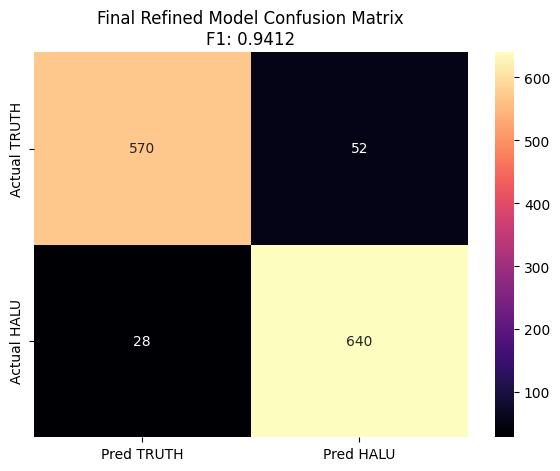

In [ ]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import torch

def generate_final_metrics(model, tokenizer, audit_dataset):
    model.eval()

    y_true = []
    y_pred = []

    print(f"🧪 Evaluating on {len(audit_dataset)} samples...")

    for item in audit_dataset:
        # --- ROBUST LABEL EXTRACTION ---
        # Hugging Face datasets usually use 'label', your dicts might use 'Actual'
        label = item.get("label") if isinstance(item, dict) else item.get("label", None)

        # Fallback if label is None (check for common alternate keys)
        if label is None:
            label = item.get("Actual") or item.get("labels")

        # Skip if label is still missing to avoid 'unknown' target error
        if label is None:
            continue

        # Convert string labels to binary
        if isinstance(label, str):
            label = 1 if "HAL" in label.upper() else 0

        # Get text
        text = item.get("text") or item.get("Text")

        # --- PREDICTION ---
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            pred = torch.argmax(logits, dim=-1).item()

        y_true.append(int(label)) # Force to integer
        y_pred.append(int(pred))  # Force to integer

    # Final check to ensure we have data
    if not y_true:
        print("❌ Error: No labels were found. Check your dataset column names.")
        return

    # Calculate Metrics
    f1 = f1_score(y_true, y_pred)

    print(f"\n🏆 FINAL F1 SCORE: {f1:.4f}")
    print("\n--- 📝 DETAILED REPORT ---")
    print(classification_report(y_true, y_pred, target_names=["Truth", "Hallucination"]))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='magma',
                xticklabels=['Pred TRUTH', 'Pred HALU'],
                yticklabels=['Actual TRUTH', 'Actual HALU'])
    plt.title(f"Final Refined Model Confusion Matrix\nF1: {f1:.4f}")
    plt.show()

# --- RUN IT ---
generate_final_metrics(model_refine, tokenizer, tokenized_split['test'])


📊 RE-CALIBRATED AUDIT REPORT
               precision    recall  f1-score   support

        Truth       0.62      0.30      0.41        93
Hallucination       0.43      0.75      0.55        67

     accuracy                           0.49       160
    macro avg       0.53      0.52      0.48       160
 weighted avg       0.54      0.49      0.47       160



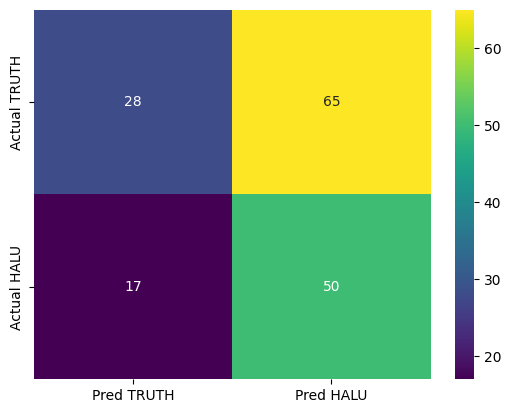

In [ ]:
def final_audit_check(model, tokenizer, audit_df):
    model.eval()
    y_true, y_pred = [], []

    # Ensure we are looking at the dataframe rows correctly
    data = audit_df.to_dict('records') if isinstance(audit_df, pd.DataFrame) else audit_df

    for item in data:
        # MAP LABELS RIGIDLY
        raw_label = item.get("Actual") or item.get("label")
        if isinstance(raw_label, str):
            # Matches "TRUTH" or "HALLUCINATION"
            label = 1 if "HAL" in raw_label.upper() else 0
        else:
            label = int(raw_label)

        text = item.get("Text") or item.get("text")

        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(device)
        with torch.no_grad():
            logits = model(**inputs).logits
            pred = torch.argmax(logits, dim=-1).item()

        y_true.append(label)
        y_pred.append(pred)

    print("\n📊 RE-CALIBRATED AUDIT REPORT")
    print(classification_report(y_true, y_pred, target_names=["Truth", "Hallucination"]))

    # Plotting to ensure both rows appear
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
                xticklabels=['Pred TRUTH', 'Pred HALU'],
                yticklabels=['Actual TRUTH', 'Actual HALU'])
    plt.show()

# Run this once to fix the 'Zero Support' issue
final_audit_check(model_refine, tokenizer, audit_results_df)

In [ ]:
def stress_test(text):
    ogmodel.eval() # Set to evaluation mode
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # 1. Tokenize
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512).to(device)

    # 2. Predict
    with torch.no_grad():
        logits = ogmodel(**inputs).logits
        probs = torch.nn.functional.softmax(logits, dim=-1)
        conf, pred = torch.max(probs, dim=-1)

    # 3. Format Output
    label = "⚠️ HALLUCINATION" if pred.item() == 1 else "✅ TRUTH"
    color = "\033[91m" if pred.item() == 1 else "\033[92m"
    reset = "\033[0m"

    print(f"Input: {text}")
    print(f"Result: {color}{label}{reset} ({conf.item()*100:.2f}% confident)\n")

# --- TRY IT OUT ---
stress_test("The capital of France is Paris.")
stress_test("The capital of France is Lyon.")
stress_test("Elon Musk founded Apple in 1976.")
stress_test("Water boils at 100 degrees Celsius at sea level.")
stress_test("If your factory isn't using much power, your Coal Generators will actually slow down or pause because they don't need to burn the fuel yet in the game satisfactory.")

Input: The capital of France is Paris.
Result: ✅ TRUTH (76.01% confident)

Input: The capital of France is Lyon.
Result: ✅ TRUTH (54.20% confident)

Input: Elon Musk founded Apple in 1976.
Result: ⚠️ HALLUCINATION (90.77% confident)

Input: Water boils at 100 degrees Celsius at sea level.
Result: ✅ TRUTH (68.94% confident)

Input: If your factory isn't using much power, your Coal Generators will actually slow down or pause because they don't need to burn the fuel yet in the game satisfactory.
Result: ⚠️ HALLUCINATION (51.54% confident)



In [ ]:
# Assuming your model is 'model' and tokenizer is 'tokenizer'
save_path = "./refinement_check"

# Save both model and tokenizer
model_refine.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model saved to {save_path}")

Model saved to ./refinement_check


In [ ]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import precision_recall_curve

# 1. Format using the correct column name 'label'
tokenized_split['test'].set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# 2. Create the DataLoader
test_dataloader = DataLoader(tokenized_split['test'], batch_size=16)

all_probs = []
all_labels = []

model_refine.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_refine.to(device)

print("Extracting probabilities...")
with torch.no_grad():
    for batch in tqdm(test_dataloader):
        # We rename 'label' to 'labels' here so the model accepts it if needed,
        # though for inference we mostly just need input_ids and attention_mask.
        inputs = {k: v.to(device) for k, v in batch.items() if k != 'label'}
        targets = batch['label'].to(device)

        logits = model_refine(**inputs).logits

        # Softmax to get the probability of the 'Hallucination' class
        # (Assuming Class 1 is Hallucination)
        probs = torch.softmax(logits, dim=-1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(targets.cpu().numpy())

# 3. Calculate Optimal Threshold
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

precision, recall, thresholds = precision_recall_curve(all_labels, all_probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_threshold = thresholds[np.argmax(f1_scores)]

print(f"\nOptimization Complete!")
print(f"New Optimal Threshold: {best_threshold:.4f}")

Extracting probabilities...


100%|██████████| 81/81 [00:14<00:00,  5.66it/s]


Optimization Complete!
New Optimal Threshold: 0.6633


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# Apply the new threshold
final_preds = (all_probs >= best_threshold).astype(int)

print("--- Optimized Audit Report ---")
print(confusion_matrix(all_labels, final_preds))
print(classification_report(all_labels, final_preds, target_names=['Truth', 'Hallucination']))

--- Optimized Audit Report ---
[[592  30]
 [ 40 628]]
               precision    recall  f1-score   support

        Truth       0.94      0.95      0.94       622
Hallucination       0.95      0.94      0.95       668

     accuracy                           0.95      1290
    macro avg       0.95      0.95      0.95      1290
 weighted avg       0.95      0.95      0.95      1290



In [ ]:
import os
import json
import shutil
import torch



# 2. Define the correct directory names
save_directory = "./modernbert_final"

# Create directory if it doesn't exist
os.makedirs(save_directory, exist_ok=True)

print("Saving model weights and tokenizer...")

# 3. Save the Model (Using FP16 to keep it small ~300MB)

model_refine.half().save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

# 4. Save the Custom Threshold config
# (Using a default if best_threshold is lost from memory)
try:
    final_thresh = float(best_threshold)
except NameError:
    final_thresh = 0.75 # Default fallback

config_data = {
    "best_threshold": final_thresh,
    "model_type": "ModernBERT-Hallucination-Detector",
    "classes": ["Truth", "Hallucination"]
}

with open(os.path.join(save_directory, "threshold_config.json"), "w") as f:
    json.dump(config_data, f, indent=4)

print(f"Model saved to {save_directory}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving model weights and tokenizer...
Model saved to ./modernbert_hallucination_optimized
Zipping the folder...
Moving ZIP to Google Drive...

SUCCESS! Go to your Google Drive and download 'modernbert_final.zip'
